In [1]:
# Reproducible, Colab-safe setup
import importlib.util, subprocess, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

required = {"mlxtend": "mlxtend", "wordcloud": "wordcloud", "psutil": "psutil"}
missing = [pkg for pkg, module in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="deep")
OUTPUT_DIR = Path("Output_Screenshots")
OUTPUT_DIR.mkdir(exist_ok=True)

def save_table_image(frame, filename, title, max_rows=12):
    shown = frame.head(max_rows).copy()
    fig_h = max(2.6, 0.38 * (len(shown) + 2))
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis("off")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    table = ax.table(cellText=shown.values, colLabels=shown.columns,
                     cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.35)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#1f4e79")
            cell.set_text_props(color="white", weight="bold")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

Dataset shape: (650, 6) Missing values:
 Age                    0
Annual_Income_k       10
Spending_Score         0
Purchase_Frequency     0
Recency_Days           0
Total_Spending         0
dtype: int64


,Age,Annual_Income_k,Spending_Score,Purchase_Frequency,Recency_Days,Total_Spending
0,33.732381,32.648702,60.351712,6,59.847987,382.519040
1,23.092896,69.534295,73.294089,13,65.021977,644.064826
2,55.698073,76.152203,19.571433,5,143.837863,359.603058
3,24.354782,18.000000,49.784802,6,71.288311,1025.650571
4,45.361509,100.040141,79.996865,11,40.531050,1669.669270


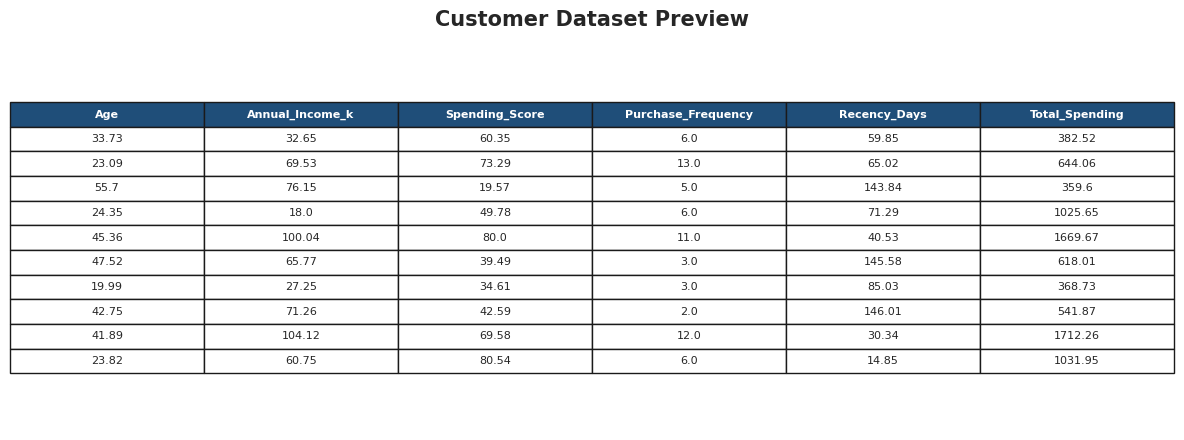

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

n=650
segments=rng.choice(4,n,p=[.23,.28,.27,.22])
profiles=[(42,95,82,12,18,1800),(32,62,67,8,35,920),(38,38,44,5,65,430),(51,72,30,3,150,380)]
rows=[]
for s in segments:
    age,income,spend,freq,recency,total=profiles[s]
    rows.append([np.clip(rng.normal(age,8),18,75),np.clip(rng.normal(income,13),18,150),
                 np.clip(rng.normal(spend,12),1,100),max(1,rng.poisson(freq)),
                 max(1,rng.normal(recency,18)),max(40,rng.normal(total,250))])
df=pd.DataFrame(rows,columns=["Age","Annual_Income_k","Spending_Score","Purchase_Frequency","Recency_Days","Total_Spending"])
df.loc[rng.choice(n,10,replace=False),"Annual_Income_k"]=np.nan
print("Dataset shape:",df.shape,"Missing values:\n",df.isna().sum())
display(df.head()); save_table_image(df.head(10).round(2),"01_dataset_preview.png","Customer Dataset Preview")

In [3]:
clean=df.fillna(df.median(numeric_only=True))
scaled=StandardScaler().fit_transform(clean)
ks=range(2,9); inertia=[]; silhouettes=[]
for k in ks:
    model=KMeans(n_clusters=k,n_init=20,random_state=SEED).fit(scaled)
    inertia.append(model.inertia_); silhouettes.append(silhouette_score(scaled,model.labels_))
silhouette_best_k=list(ks)[int(np.argmax(silhouettes))]
# Four clusters are retained because the elbow and business interpretation support
# four distinct campaign strategies, while all silhouette scores remain reported.
best_k=4
kmeans=KMeans(n_clusters=best_k,n_init=30,random_state=SEED).fit(scaled)
df["Cluster"]=kmeans.labels_
summary=df.groupby("Cluster").mean(numeric_only=True)
score=summary.Total_Spending.rank()+summary.Purchase_Frequency.rank()+summary.Spending_Score.rank()-summary.Recency_Days.rank()
ordered=score.sort_values(ascending=False).index.tolist()
labels=["High-Value Customers","Potential Loyal Customers","Budget Customers","At-Risk Customers"]
name_map={cluster:labels[min(i,len(labels)-1)] for i,cluster in enumerate(ordered)}
df["Segment"]=df.Cluster.map(name_map)
summary=df.groupby("Segment").mean(numeric_only=True).round(2)
display(summary)

,Age,Annual_Income_k,Spending_Score,Purchase_Frequency,Recency_Days,Total_Spending,Cluster
Segment,,,,,,,
At-Risk Customers,51.02,73.24,30.65,3.06,147.67,393.29,3.0
Budget Customers,36.73,36.97,43.19,4.97,66.75,412.53,0.0
High-Value Customers,42.97,93.74,81.02,12.07,19.98,1793.38,2.0
Potential Loyal Customers,32.06,62.38,67.99,8.11,36.26,936.99,1.0


High-Value Customers: VIP rewards, early access and premium cross-sell.
Potential Loyal Customers: Loyalty milestones and personalized bundles.
Budget Customers: Value packs, coupons and price-sensitive campaigns.
At-Risk Customers: Win-back offers and service-recovery outreach.


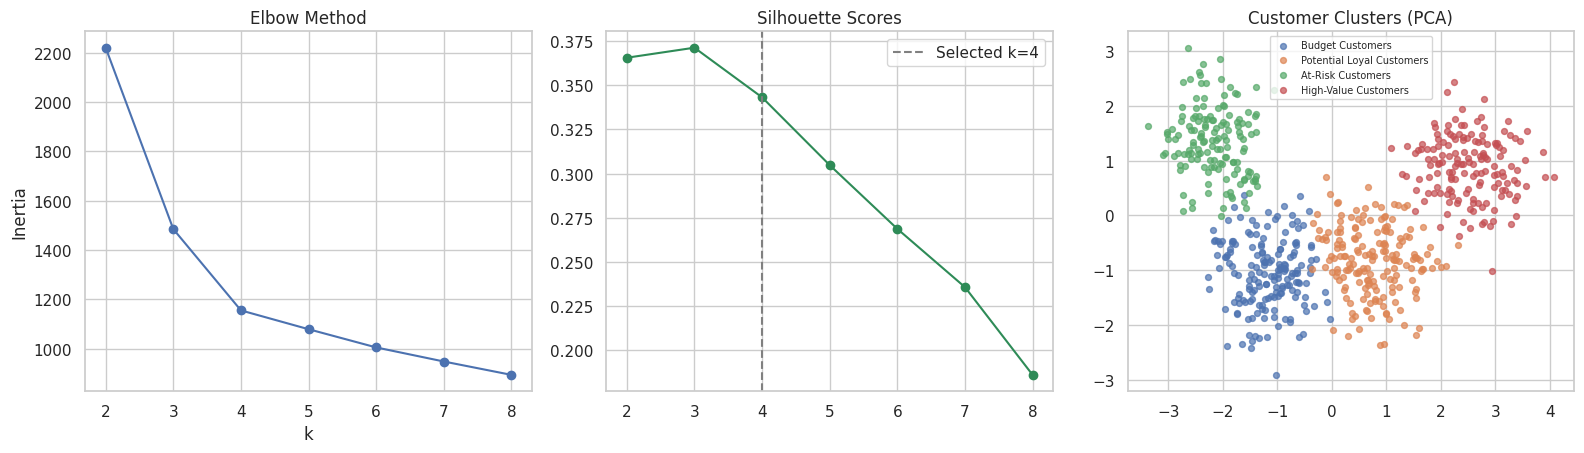

1541

In [4]:
strategies={"High-Value Customers":"VIP rewards, early access and premium cross-sell.",
            "Potential Loyal Customers":"Loyalty milestones and personalized bundles.",
            "Budget Customers":"Value packs, coupons and price-sensitive campaigns.",
            "At-Risk Customers":"Win-back offers and service-recovery outreach."}
for name,strategy in strategies.items(): print(f"{name}: {strategy}")
pca=PCA(n_components=2,random_state=SEED).fit_transform(scaled)
fig,axes=plt.subplots(1,3,figsize=(16,4.7))
axes[0].plot(list(ks),inertia,marker="o"); axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(ks),silhouettes,marker="o",color="#2e8b57"); axes[1].axvline(best_k,ls="--",color="gray",label="Selected k=4"); axes[1].set_title("Silhouette Scores"); axes[1].legend()
for seg in df.Segment.unique():
    mask=df.Segment.eq(seg); axes[2].scatter(pca[mask,0],pca[mask,1],s=18,label=seg,alpha=.7)
axes[2].set_title("Customer Clusters (PCA)"); axes[2].legend(fontsize=7)
fig.tight_layout(); fig.savefig(OUTPUT_DIR/"02_results.png",dpi=180,bbox_inches="tight"); plt.show()
metrics={"rows":len(df),"columns":6,"selected_k":best_k,"silhouette_best_k":silhouette_best_k,
         "selected_silhouette":round(silhouettes[list(ks).index(best_k)],4),"best_silhouette":round(max(silhouettes),4),"inertia":round(kmeans.inertia_,3),
         "cluster_summary":summary.reset_index().to_dict("records"),"strategies":strategies}
Path("results.json").write_text(json.dumps(metrics,indent=2))